# Step 5 - Transformations for Stationarity

This notebook compares practical transformations for the imputed PJM East hourly demand series. The goal is to choose a version of the series that is easier to model with SARIMA while still preserving interpretable demand dynamics.


In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from statsmodels.tsa.stattools import adfuller, kpss

PROCESSED_PATH = "../data/processed/"
FIGURES_PATH = "../reports/figures/"
TEST_SAMPLE_HOURS = 24 * 365 * 2

os.makedirs(FIGURES_PATH, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")

df = pd.read_csv(
    os.path.join(PROCESSED_PATH, "pjme_imputed.csv"),
    parse_dates=["Datetime"],
    index_col="Datetime",
).sort_index()

series = df["PJME_MW"].astype(float)

print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Missing values: {int(series.isna().sum())}")
df.head()


Shape: (145392, 1)
Date range: 2002-01-01 01:00:00 to 2018-08-03 00:00:00
Missing values: 0


,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


In [2]:
transformed_candidates = {
    "raw": series,
    "log": np.log(series),
    "diff_1": series.diff(),
    "diff_24": series.diff(24),
    "log_diff_1": np.log(series).diff(),
    "log_diff_24": np.log(series).diff(24),
    "diff_1_diff_24": series.diff().diff(24),
    "log_diff_1_diff_24": np.log(series).diff().diff(24),
}


def run_stationarity_tests(name: str, ts: pd.Series) -> dict:
    sample = ts.dropna().iloc[-TEST_SAMPLE_HOURS:]

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        adf_result = adfuller(sample, autolag="AIC")
        kpss_result = kpss(sample, regression="c", nlags="auto")

    return {
        "transformation": name,
        "n_test_points": len(sample),
        "mean": sample.mean(),
        "std": sample.std(),
        "acf_lag_1": sample.autocorr(1),
        "acf_lag_24": sample.autocorr(24),
        "acf_lag_168": sample.autocorr(168),
        "adf_stat": adf_result[0],
        "adf_p_value": adf_result[1],
        "kpss_stat": kpss_result[0],
        "kpss_p_value": kpss_result[1],
    }


transformation_summary = pd.DataFrame(
    [run_stationarity_tests(name, ts) for name, ts in transformed_candidates.items()]
).sort_values(["kpss_p_value", "adf_p_value"], ascending=[False, True])

display(
    transformation_summary.style.format(
        {
            "mean": "{:,.5f}",
            "std": "{:,.5f}",
            "acf_lag_1": "{:,.4f}",
            "acf_lag_24": "{:,.4f}",
            "acf_lag_168": "{:,.4f}",
            "adf_stat": "{:,.4f}",
            "adf_p_value": "{:,.6f}",
            "kpss_stat": "{:,.4f}",
            "kpss_p_value": "{:,.6f}",
        }
    )
)


,transformation,n_test_points,mean,std,acf_lag_1,acf_lag_24,acf_lag_168,adf_stat,adf_p_value,kpss_stat,kpss_p_value
2,diff_1,17520,0.18864,"1,344.13854",0.8524,0.9194,0.9145,-24.5545,0.000000,0.0030,0.100000
3,diff_24,17520,3.83721,"3,066.78222",0.9845,0.0131,0.2577,-23.8926,0.000000,0.0163,0.100000
4,log_diff_1,17520,0.00001,0.04355,0.8512,0.9244,0.9344,-24.7724,0.000000,0.0042,0.100000
5,log_diff_24,17520,0.00010,0.09502,0.9842,0.0106,0.2996,-24.3751,0.000000,0.0155,0.100000
6,diff_1_diff_24,17520,-0.01199,539.20299,0.7547,-0.1773,0.3765,-26.3432,0.000000,0.0009,0.100000
7,log_diff_1_diff_24,17520,-0.00000,0.01692,0.7413,-0.1664,0.4496,-25.9458,0.000000,0.0008,0.100000
1,log,17520,10.32699,0.19587,0.9753,0.8821,0.7295,-7.9815,0.000000,0.4315,0.063568
0,raw,17520,"31,149.25437","6,334.03895",0.9775,0.8825,0.7032,-7.8880,0.000000,0.4361,0.061581


The table gives a practical comparison rather than a single-rule answer. For this project the strongest candidate is usually the transformation that combines variance stabilization with both short-run and daily differencing, because the raw hourly demand series still carries large level shifts and obvious 24-hour structure.


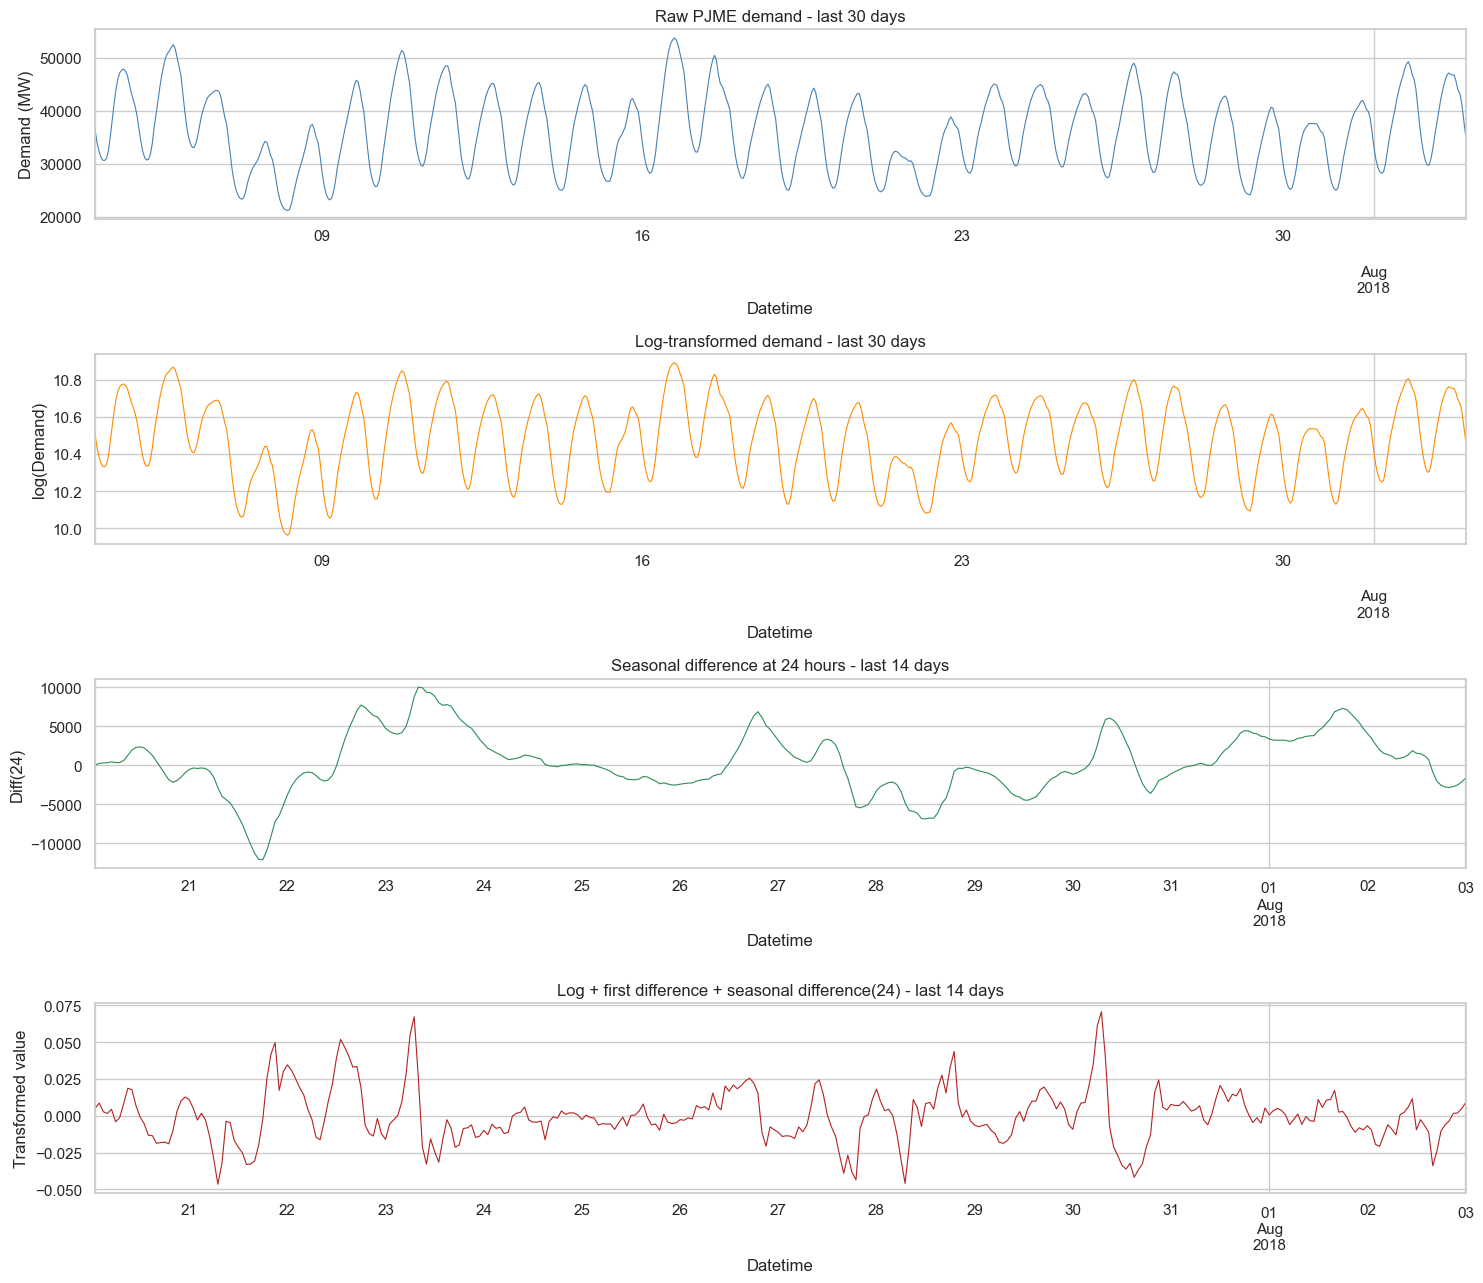

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(15, 13), sharex=False)

series.iloc[-24 * 30 :].plot(ax=axes[0], color="steelblue", linewidth=0.8)
axes[0].set_title("Raw PJME demand - last 30 days")
axes[0].set_ylabel("Demand (MW)")

np.log(series).iloc[-24 * 30 :].plot(ax=axes[1], color="darkorange", linewidth=0.8)
axes[1].set_title("Log-transformed demand - last 30 days")
axes[1].set_ylabel("log(Demand)")

series.diff(24).iloc[-24 * 14 :].plot(ax=axes[2], color="seagreen", linewidth=0.8)
axes[2].set_title("Seasonal difference at 24 hours - last 14 days")
axes[2].set_ylabel("Diff(24)")

transformed_candidates["log_diff_1_diff_24"].iloc[-24 * 14 :].plot(
    ax=axes[3], color="firebrick", linewidth=0.8
)
axes[3].set_title("Log + first difference + seasonal difference(24) - last 14 days")
axes[3].set_ylabel("Transformed value")
axes[3].set_xlabel("Datetime")

plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_PATH, "05_transformations_overview.png"),
    dpi=150,
    bbox_inches="tight",
)
plt.show()


The visual comparison should show the same story as the test table: logging reduces scale effects, but differencing is what removes the persistent daily level shifts. After applying both first differencing and 24-hour seasonal differencing, the series fluctuates around a more stable center and becomes much more suitable for SARIMA diagnostics.


In [4]:
selected_name = "log_diff_1_diff_24"
selected_series = transformed_candidates[selected_name].dropna().rename("PJME_MW_transformed")

transformation_summary["selected_for_modeling"] = (
    transformation_summary["transformation"] == selected_name
)
transformation_summary.to_csv(
    os.path.join(PROCESSED_PATH, "transformation_summary.csv"), index=False
)
selected_series.to_frame().to_csv(os.path.join(PROCESSED_PATH, "pjme_transformed.csv"))

selection_summary = pd.DataFrame(
    [
        {
            "selected_transformation": selected_name,
            "reason": "Balances variance stabilization with non-seasonal and daily differencing for hourly SARIMA modeling.",
            "seasonal_period_for_modeling": 24,
        }
    ]
)
selection_summary.to_csv(
    os.path.join(PROCESSED_PATH, "transformation_selection.csv"), index=False
)

print("Saved transformation summary to ../data/processed/transformation_summary.csv")
print("Saved selected transformed series to ../data/processed/pjme_transformed.csv")
display(selection_summary)
selected_series.head()


Saved transformation summary to ../data/processed/transformation_summary.csv
Saved selected transformed series to ../data/processed/pjme_transformed.csv


,selected_transformation,reason,seasonal_period_for_modeling
0,log_diff_1_diff_24,Balances variance stabilization with non-seaso...,24


Datetime
2002-01-02 02:00:00    0.013196
2002-01-02 03:00:00    0.026549
2002-01-02 04:00:00    0.024745
2002-01-02 05:00:00    0.025533
2002-01-02 06:00:00    0.058205
Name: PJME_MW_transformed, dtype: float64

Final decision: continue the workflow with `log(PJME_MW)` differenced once and seasonally differenced at 24 hours. That keeps the modeling setup consistent with the strong daily demand cycle and gives the next notebooks a working series for seasonal diagnostics and order selection.
